In [1]:
import os, random, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import save_image
from PIL import Image
import matplotlib.pyplot as plt

# ── reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [2]:
# ── image & watermark ────────────────────────────────────────────────────────
IMG_SIZE    = 128        # 128×128 keeps VRAM well under 16 GB; use 256 if desired
WATERMARK_BITS = 32      # binary copyright message length

# ── data ─────────────────────────────────────────────────────────────────────
DATA_DIR = "/kaggle/input/datasets/soumikrakshit/div2k-high-resolution-images/DIV2K_train_HR/DIV2K_train_HR"
VAL_DIR = "/kaggle/input/datasets/soumikrakshit/div2k-high-resolution-images/DIV2K_valid_HR/DIV2K_valid_HR"
NUM_TRAIN   = 800        # DIV2K train set size
NUM_VAL     = 100        # DIV2K val set size

# ── training ─────────────────────────────────────────────────────────────────
BATCH_SIZE  = 4          # safe for T4 at 128×128; lower to 4 if OOM
EPOCHS      = 80         # Extended for better convergence
LR          = 1e-4
GRAD_CLIP   = 1.0

# ── loss weights (λ1 image, λ2 watermark, λ3 perceptual placeholder) ─────────
LAMBDA_IMG  = 1.5
LAMBDA_WM   = 6.5         # slightly upweight watermark recovery
LAMBDA_PERC = 0.02        # set > 0 after initial training stabilises

# ── model dims (compact Transformer) ────────────────────────────────────────
EMBED_DIM   = 128         # patch embedding channels
PATCH_SIZE  = 8          # 8×8 patches → 16×16 grid for 128-img
NUM_HEADS   = 8
DEPTH       = 6          # transformer blocks per stage
MLP_RATIO   = 2.0

# ── output dir ───────────────────────────────────────────────────────────────
OUT_DIR = '/kaggle/working/outputs'
os.makedirs(OUT_DIR, exist_ok=True)
print('Config loaded.')

Config loaded.


In [3]:
class PatchEmbed(nn.Module):
    """Split image into non-overlapping patches and project to embed_dim."""

    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_ch=3, embed_dim=EMBED_DIM):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_ch, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: (B, C, H, W)  →  (B, N, embed_dim)
        x = self.proj(x)               # (B, embed_dim, H/P, W/P)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)  # (B, N, C)
        return x, H, W


class TransformerBlock(nn.Module):
    """Standard pre-norm Transformer block with GELU MLP."""

    def __init__(self, dim, num_heads, mlp_ratio=2.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        hidden     = int(dim * mlp_ratio)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # Self-attention with residual
        h = self.norm1(x)
        h, _ = self.attn(h, h, h)
        x = x + h
        # MLP with residual
        x = x + self.mlp(self.norm2(x))
        return x


class PatchUnembed(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, patch_size=PATCH_SIZE, out_ch=3):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Sequential(
            nn.ConvTranspose2d(embed_dim, embed_dim // 2, 3, padding=1),
            nn.GELU(),
            nn.ConvTranspose2d(embed_dim // 2, out_ch,
                               kernel_size=patch_size, stride=patch_size),
        )
        # Original safe init — small normal weights
        for m in self.proj:
            if isinstance(m, nn.ConvTranspose2d):
                nn.init.normal_(m.weight, std=0.02)
                nn.init.constant_(m.bias, 0.0)

    def forward(self, x, H, W):
        B, N, C = x.shape
        x = x.transpose(1, 2).reshape(B, C, H, W)
        return self.proj(x)

In [4]:
class WatermarkDataset(Dataset):
    """Returns (image_tensor, random_binary_watermark) pairs."""

    def __init__(self, img_dir, size=IMG_SIZE, limit=None, augment=False):
        exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
        self.paths = sorted([
            os.path.join(img_dir, f)
            for f in os.listdir(img_dir)
            if os.path.splitext(f)[1].lower() in exts
        ])
        if limit:
            self.paths = self.paths[:limit]

        aug_list = []
        if augment:
            aug_list += [
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
                transforms.RandomResizedCrop(size, scale=(0.8, 1.0)),
            ]
        else:
            aug_list.append(transforms.CenterCrop(size))

        self.transform = transforms.Compose([
            transforms.Resize(size + 16),   # a little extra for crop headroom
            *aug_list,
            transforms.Resize(size),        # ensure exact size
            transforms.ToTensor(),           # [0, 1]
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        img = self.transform(img)
        wm  = torch.randint(0, 2, (WATERMARK_BITS,)).float()  # random binary message
        return img, wm


train_ds = WatermarkDataset(DATA_DIR, limit=NUM_TRAIN, augment=True)
val_ds   = WatermarkDataset(VAL_DIR,  limit=NUM_VAL,   augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} images · Val: {len(val_ds)} images')
print(f'Train batches: {len(train_loader)} · Val batches: {len(val_loader)}')

Train: 800 images · Val: 100 images
Train batches: 200 · Val batches: 25


In [5]:
class WatermarkExtractor(nn.Module):
    """
    Takes a (possibly attacked) watermarked image and predicts the binary
    watermark bits.
    1. Patch-embed the image  →  token sequence
    2. Prepend learnable pool token
    3. Run Transformer blocks
    4. Extract pool token output → MLP head → logits over WATERMARK_BITS
    """
    def __init__(self):
        super().__init__()
        self.patch_embed = PatchEmbed()
        num_patches      = self.patch_embed.num_patches

        self.pool_token = nn.Parameter(torch.zeros(1, 1, EMBED_DIM))
        nn.init.trunc_normal_(self.pool_token, std=0.02)

        # +1 for the pool token prepended before blocks
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, EMBED_DIM))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        self.blocks = nn.ModuleList([
            TransformerBlock(EMBED_DIM, NUM_HEADS, MLP_RATIO) for _ in range(DEPTH)
        ])
        self.norm = nn.LayerNorm(EMBED_DIM)

        self.head = nn.Sequential(
            nn.Linear(EMBED_DIM, EMBED_DIM * 4),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(EMBED_DIM * 4, EMBED_DIM * 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(EMBED_DIM * 2, WATERMARK_BITS),
        )

    def forward(self, img):
        tokens, _, _ = self.patch_embed(img)              # (B, N, C)

        # Prepend pool token BEFORE blocks so it attends to all patches
        pool = self.pool_token.expand(img.shape[0], -1, -1)  # (B, 1, C)
        tokens = torch.cat([pool, tokens], dim=1)             # (B, N+1, C)
        tokens = tokens + self.pos_embed                      # pos embed covers N+1

        for blk in self.blocks:
            tokens = blk(tokens)
        tokens = self.norm(tokens)

        pooled = tokens[:, 0]                             # (B, C) — pool token output
        logits = self.head(pooled)                        # (B, bits) — raw logits
        return logits

print('Extractor defined.')

Extractor defined.


In [6]:
class WatermarkEmbedder(nn.Module):
    """
    Takes (image, watermark_bits) and returns watermarked_image.

    1. Patch-embed the image  →  token sequence
    2. Expand & inject the watermark bits as a learned offset
    3. Run Transformer blocks
    4. Reconstruct the spatial image via PatchUnembed
    5. Add residual from original image for imperceptibility
    """

    def __init__(self):
        super().__init__()
        self.patch_embed   = PatchEmbed()
        num_patches        = self.patch_embed.num_patches

        # Project watermark bits to per-token injection vector
        self.wm_proj    = nn.Linear(WATERMARK_BITS, EMBED_DIM)
        self.cross_attn = nn.MultiheadAttention(EMBED_DIM, NUM_HEADS, batch_first=True)
        self.cross_norm = nn.LayerNorm(EMBED_DIM)

        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, EMBED_DIM))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        self.blocks      = nn.ModuleList([
            TransformerBlock(EMBED_DIM, NUM_HEADS, MLP_RATIO) for _ in range(DEPTH)
        ])
        self.norm        = nn.LayerNorm(EMBED_DIM)
        self.patch_unembed = PatchUnembed(out_ch=3)
        self.out_act     = nn.Tanh()  # small residual in [-1, 1]


        ###############################################################
        self.residual_scale = nn.Parameter(torch.tensor(0.15))  # starts at 0.3, learned
        ###############################################################

    def forward(self, img, wm):
        # img: (B, 3, H, W) · wm: (B, bits)
        tokens, H, W = self.patch_embed(img)        # (B, N, C)
        tokens = tokens + self.pos_embed

        # Broadcast watermark to every token
        # In WatermarkEmbedder.forward():
        wm_key = self.wm_proj(wm).unsqueeze(1)   # (B, 1, C) — watermark as key/value
        for blk in self.blocks:
            # Cross-attend: tokens query the watermark
            attended, _ = self.cross_attn(tokens, wm_key, wm_key)
            tokens = self.cross_norm(tokens + attended)
            tokens = blk(tokens)

        residual    = self.out_act(self.patch_unembed(tokens, H, W))
        watermarked = torch.clamp(img + self.residual_scale.clamp(0.15, 0.40) * residual, 0.0, 1.0)
        return watermarked


print('Embedder defined.')

Embedder defined.


In [7]:
class AttackLayer(nn.Module):
    """
    Randomly applies one of: Gaussian noise · JPEG-approx blur ·
    resize-down-up · random crop-pad · identity.
    All ops are differentiable (or treated as pass-through for gradients).
    """

    def __init__(self, p=0.8):
        super().__init__()
        self.p = p  # probability of applying any attack
        self.current_epoch = 0

    # Replace AttackLayer.forward() with this:
    def forward(self, x):
        if not self.training:
            return x
        
        # Ramp: no attacks early, full attacks late
        p = min(0.8, max(0.0, (self.current_epoch - 15) / 20 * 0.8))
        
        if random.random() > p:
            return x   # pass clean image most of the time early on
        
        # Also limit attack severity early
        severity = min(1.0, (self.current_epoch - 15) / 20)
        
        attack = random.choice(['noise', 'blur', 'resize', 'identity'])
        # Remove 'crop' entirely — it's the hardest attack and rarely seen online
        
        if attack == 'noise':
            sigma = 0.01 * severity   # was 0.05 max
            x = torch.clamp(x + sigma * torch.randn_like(x), 0, 1)
        elif attack == 'blur':
            if severity > 0.5:
                factor = 2   # was up to 4
                H, W = x.shape[-2:]
                x = F.avg_pool2d(x, factor)
                x = F.interpolate(x, (H, W), mode='bilinear', align_corners=False)
        elif attack == 'resize':
            scale = 1.0 - 0.3 * severity   # was down to 0.5
            H, W = x.shape[-2:]
            nh, nw = max(32, int(H * scale)), max(32, int(W * scale))
            x = F.interpolate(x, (nh, nw), mode='bilinear', align_corners=False)
            x = F.interpolate(x, (H, W), mode='bilinear', align_corners=False)
        return x


print('AttackLayer defined.')

AttackLayer defined.


In [8]:
embedder  = WatermarkEmbedder().to(DEVICE)
extractor = WatermarkExtractor().to(DEVICE)
attack    = AttackLayer(p=0.0).to(DEVICE)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Embedder  params : {count_params(embedder):,}')
print(f'Extractor params : {count_params(extractor):,}')
print(f'Total params     : {count_params(embedder) + count_params(extractor):,}')

Embedder  params : 1,009,220
Extractor params : 1,058,464
Total params     : 2,067,684


In [9]:
# ── loss ─────────────────────────────────────────────────────────────────────
mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()


def total_loss(orig, watermarked, wm_true, wm_logits):
    l_img = mse_loss(watermarked, orig)
    l_wm  = bce_loss(wm_logits, wm_true)
    # l_perc = perceptual_loss(orig, watermarked)

    # Target: keep PSNR above ~33 dB (MSE ~ 0.0005)
    # Penalise only when MSE exceeds the target — don't reward going lower
    MSE_TARGET = 0.0005
    l_img_penalty = torch.clamp(l_img / MSE_TARGET - 1.0, min=0.0)
    # After image quality
    # loss = LAMBDA_IMG * l_img_penalty + LAMBDA_WM * l_wm + LAMBDA_PERC * l_perc
    loss = LAMBDA_IMG * l_img_penalty + LAMBDA_WM * l_wm
    
    return loss, l_img.item(), l_wm.item()


# ── metrics ──────────────────────────────────────────────────────────────────
def psnr(orig, recon):
    mse = mse_loss(recon, orig).item()
    if mse == 0:
        return float('inf')
    return 10 * math.log10(1.0 / mse)

def ssim_approx(orig, recon):
    """Lightweight SSIM approximation (no external lib needed)."""
    mu1, mu2   = orig.mean(), recon.mean()
    sig1, sig2 = orig.std(),  recon.std()
    sig12      = ((orig - mu1) * (recon - mu2)).mean()
    C1, C2     = (0.01 ** 2), (0.03 ** 2)
    num   = (2 * mu1 * mu2 + C1) * (2 * sig12 + C2)
    denom = (mu1 ** 2 + mu2 ** 2 + C1) * (sig1 ** 2 + sig2 ** 2 + C2)
    return (num / denom).item()

def ber(wm_true, wm_logits):
    """Bit Error Rate: fraction of bits decoded incorrectly."""
    pred = (torch.sigmoid(wm_logits) > 0.5).float()
    return (pred != wm_true).float().mean().item()

def extraction_accuracy(wm_true, wm_logits):
    pred = (torch.sigmoid(wm_logits) > 0.5).float()
    per_sample = (pred == wm_true).float().mean(dim=1)  # per-message accuracy
    return per_sample.mean().item()

print('Loss functions and metrics defined.')

Loss functions and metrics defined.


In [10]:
# UPDATED Section 5 — define optimizer, scheduler, and scaler once:
params    = list(embedder.parameters()) + list(extractor.parameters())
optimizer = torch.optim.AdamW(
    list(embedder.parameters()) + list(extractor.parameters()),
    lr=LR,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=60,       # important: use 60 even if EPOCHS = 20
    eta_min=1e-6
)
scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

history = {'train_loss': [], 'val_loss': [], 'psnr': [],
           'ssim': [], 'ber': [], 'acc': []}


/tmp/ipykernel_9495/1571920730.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))


In [11]:
# Quick loss scale check — run after Section 5:
imgs, wms = next(iter(train_loader))
imgs, wms = imgs.to(DEVICE), wms.to(DEVICE)
with torch.no_grad():
    with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
        watermarked = embedder(imgs, wms)
        wm_logits   = extractor(watermarked)
        loss, li, lw = total_loss(imgs, watermarked, wms, wm_logits)
        print(f'Loss  : {loss.item():.4f}')
        print(f'img   : {li:.6f}')
        print(f'wm    : {lw:.4f}')
        print(f'Expected total ~3.5 if LAMBDA_WM=5.0')

Loss  : 4.5344
img   : 0.000078
wm    : 0.6976
Expected total ~3.5 if LAMBDA_WM=5.0


In [12]:
history = {'train_loss': [], 'val_loss': [], 'psnr': [],
           'ssim': [], 'ber': [], 'acc': []}


def train_epoch(epoch):
    embedder.train(); extractor.train(); attack.train()
    total, img_l, wm_l = 0.0, 0.0, 0.0

    for imgs, wms in train_loader:
        imgs, wms = imgs.to(DEVICE), wms.to(DEVICE)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
            watermarked = embedder(imgs, wms)
            attacked    = attack(watermarked)
            wm_logits   = extractor(attacked)
            loss, li, lw = total_loss(imgs, watermarked, wms, wm_logits)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(params, GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        total += loss.item()
        img_l += li
        wm_l  += lw

    n = len(train_loader)
    return total / n, img_l / n, wm_l / n


@torch.no_grad()
def val_epoch():
    embedder.eval(); extractor.eval(); attack.eval()
    v_loss, v_psnr, v_ssim, v_ber, v_acc = 0.0, 0.0, 0.0, 0.0, 0.0

    for imgs, wms in val_loader:
        imgs, wms = imgs.to(DEVICE), wms.to(DEVICE)

        with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
            watermarked = embedder(imgs, wms)
            wm_logits   = extractor(watermarked)   # no attack at val time
            loss, _, _  = total_loss(imgs, watermarked, wms, wm_logits)

        v_loss += loss.item()
        v_psnr += psnr(imgs, watermarked)
        v_ssim += ssim_approx(imgs, watermarked)
        v_ber  += ber(wms, wm_logits)
        v_acc  += extraction_accuracy(wms, wm_logits)

    n = len(val_loader)
    return v_loss/n, v_psnr/n, v_ssim/n, v_ber/n, v_acc/n


print('Train/val loops defined.')

Train/val loops defined.


In [13]:
embedder.train()
imgs, wms = next(iter(train_loader))
imgs, wms = imgs.to(DEVICE), wms.to(DEVICE)
with torch.no_grad():
    out = embedder(imgs, wms)
    diff = (out - imgs).abs()
    print(f'PSNR        : {10 * math.log10(1.0 / diff.pow(2).mean().item()):.2f} dB')
    print(f'Mean diff   : {diff.mean().item():.6f}')
    print(f'Scale value : {embedder.residual_scale}')   # plain float, no .item()
    print(f'Has out_proj: {hasattr(embedder, "out_proj")}')
    print(f'Has out_act : {hasattr(embedder, "out_act")}')

PSNR        : 40.74 dB
Mean diff   : 0.007153
Scale value : Parameter containing:
tensor(0.1500, device='cuda:0', requires_grad=True)
Has out_proj: False
Has out_act : True


In [14]:
PHASE1_EPOCHS = 15
best_ber = float('inf')

for epoch in range(1, EPOCHS + 1):

    if epoch <= PHASE1_EPOCHS:
        for p in embedder.parameters():
            p.requires_grad = True
        for p in extractor.parameters():
            p.requires_grad = False

        if epoch == 1:
            print('>>> Phase 1: embedder-only training (extractor frozen)')

    else:
        for p in embedder.parameters():
            p.requires_grad = True
        for p in extractor.parameters():
            p.requires_grad = True

        if epoch == PHASE1_EPOCHS + 1:
            print('>>> Phase 2: joint training (all unfrozen)')

    t0 = time.time()
    attack.current_epoch = epoch

    tr_loss, tr_img, tr_wm = train_epoch(epoch)
    vl_loss, vl_psnr, vl_ssim, vl_ber, vl_acc = val_epoch()

    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['psnr'].append(vl_psnr)
    history['ssim'].append(vl_ssim)
    history['ber'].append(vl_ber)
    history['acc'].append(vl_acc)

    elapsed = time.time() - t0
    lr_now  = scheduler.get_last_lr()[0]

    print(f'Epoch {epoch:03d}/{EPOCHS}  '
          f'tr={tr_loss:.4f} (img={tr_img:.4f} wm={tr_wm:.4f})  '
          f'val={vl_loss:.4f}  PSNR={vl_psnr:.2f} dB  '
          f'SSIM={vl_ssim:.4f}  BER={vl_ber:.4f}  '
          f'Acc={vl_acc:.4f}  LR={lr_now:.2e}  {elapsed:.1f}s')

    if vl_ber < best_ber:
        best_ber = vl_ber
        torch.save({
            "embedder": embedder.state_dict(),
            "extractor": extractor.state_dict(),
            "epoch": epoch,
            "val_loss": vl_loss,
            "psnr": vl_psnr,
            "ssim": vl_ssim,
            "ber": vl_ber,
            "acc": vl_acc,
        }, f"{OUT_DIR}/best_model_ber.pth")
        print(f"  ↳ best BER model saved (BER={vl_ber:.4f}, Acc={vl_acc:.4f})")

print('\nTraining complete.')
print(f'Accuracy = {(1 - best_ber) * 100:.2f}%')

>>> Phase 1: embedder-only training (extractor frozen)
Epoch 001/80  tr=4.5117 (img=0.0003 wm=0.6931)  val=4.5032  PSNR=34.02 dB  SSIM=0.9967  BER=0.4659  Acc=0.5341  LR=9.99e-05  50.2s
  ↳ best BER model saved (BER=0.4659, Acc=0.5341)
Epoch 002/80  tr=4.5056 (img=0.0004 wm=0.6916)  val=4.4955  PSNR=33.87 dB  SSIM=0.9967  BER=0.4697  Acc=0.5303  LR=9.97e-05  50.2s
Epoch 003/80  tr=4.5036 (img=0.0004 wm=0.6914)  val=4.4982  PSNR=34.71 dB  SSIM=0.9972  BER=0.4669  Acc=0.5331  LR=9.94e-05  50.1s
Epoch 004/80  tr=4.5027 (img=0.0004 wm=0.6917)  val=4.4957  PSNR=33.49 dB  SSIM=0.9964  BER=0.4500  Acc=0.5500  LR=9.89e-05  49.9s
  ↳ best BER model saved (BER=0.4500, Acc=0.5500)
Epoch 005/80  tr=4.4992 (img=0.0004 wm=0.6914)  val=4.4974  PSNR=33.86 dB  SSIM=0.9966  BER=0.4562  Acc=0.5437  LR=9.83e-05  50.8s
Epoch 006/80  tr=4.4988 (img=0.0004 wm=0.6912)  val=4.4935  PSNR=34.85 dB  SSIM=0.9973  BER=0.4575  Acc=0.5425  LR=9.76e-05  51.3s
Epoch 007/80  tr=4.4990 (img=0.0004 wm=0.6913)  val=4.4991 

In [15]:
# ── Fine-tune from best checkpoint ───────────────────────────────────────────
FINETUNE_EPOCHS = 35
FINETUNE_LR     = 5e-5   # warm restart — higher than where cosine left off

# Load best checkpoint
ckpt = torch.load(f'{OUT_DIR}/best_model_ber.pth', map_location=DEVICE)
embedder.load_state_dict(ckpt['embedder'])
extractor.load_state_dict(ckpt['extractor'])
print(f'Loaded best checkpoint from epoch {ckpt["epoch"]}')

# Fresh optimizer + scheduler — both networks unfrozen
optimizer = torch.optim.AdamW(
    list(embedder.parameters()) + list(extractor.parameters()),
    lr=FINETUNE_LR, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=FINETUNE_EPOCHS, eta_min=1e-6
)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

# Increase watermark loss weight to push harder on BER
LAMBDA_WM = 6.5   # was 5.0

best_val_loss = float('inf')

for epoch in range(1, FINETUNE_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_img, tr_wm = train_epoch(epoch)
    vl_loss, vl_psnr, vl_ssim, vl_ber, vl_acc = val_epoch()
    scheduler.step()

    elapsed = time.time() - t0
    lr_now  = scheduler.get_last_lr()[0]

    print(f'FT Epoch {epoch:03d}/{FINETUNE_EPOCHS}  '
          f'tr={tr_loss:.4f} (img={tr_img:.4f} wm={tr_wm:.4f})  '
          f'val={vl_loss:.4f}  PSNR={vl_psnr:.2f} dB  '
          f'SSIM={vl_ssim:.4f}  BER={vl_ber:.4f}  '
          f'Acc={vl_acc:.4f}  LR={lr_now:.2e}  {elapsed:.1f}s')

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save({'embedder':  embedder.state_dict(),
                    'extractor': extractor.state_dict(),
                    'epoch':     epoch},
                   f'{OUT_DIR}/best_model_ft.pth')
        print(f'  ↳ best fine-tuned model saved')

print(f'\nFine-tuning complete.')
print(f'Final BER: {vl_ber:.4f}  |  Accuracy: {(1-vl_ber)*100:.2f}%')

Loaded best checkpoint from epoch 65


/tmp/ipykernel_9495/3629585477.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))


FT Epoch 001/35  tr=2.8219 (img=0.0004 wm=0.4338)  val=2.5353  PSNR=33.73 dB  SSIM=0.9965  BER=0.1841  Acc=0.8159  LR=4.99e-05  50.8s
  ↳ best fine-tuned model saved
FT Epoch 002/35  tr=2.8155 (img=0.0004 wm=0.4328)  val=2.5016  PSNR=33.91 dB  SSIM=0.9966  BER=0.1762  Acc=0.8237  LR=4.96e-05  51.1s
  ↳ best fine-tuned model saved
FT Epoch 003/35  tr=2.7187 (img=0.0004 wm=0.4176)  val=2.3731  PSNR=33.76 dB  SSIM=0.9965  BER=0.1672  Acc=0.8328  LR=4.91e-05  50.3s
  ↳ best fine-tuned model saved
FT Epoch 004/35  tr=2.6708 (img=0.0004 wm=0.4105)  val=2.4083  PSNR=33.63 dB  SSIM=0.9964  BER=0.1703  Acc=0.8297  LR=4.84e-05  50.1s
FT Epoch 005/35  tr=2.7273 (img=0.0004 wm=0.4187)  val=2.4307  PSNR=33.51 dB  SSIM=0.9963  BER=0.1744  Acc=0.8256  LR=4.76e-05  50.1s
FT Epoch 006/35  tr=2.6672 (img=0.0004 wm=0.4098)  val=2.3508  PSNR=33.80 dB  SSIM=0.9966  BER=0.1659  Acc=0.8341  LR=4.65e-05  50.5s
  ↳ best fine-tuned model saved
FT Epoch 007/35  tr=2.6406 (img=0.0004 wm=0.4059)  val=2.2153  PSNR=

In [16]:
# Second fine-tune — load best fine-tuned model
FINETUNE2_EPOCHS = 20
FINETUNE2_LR     = 2e-5   # lower than first fine-tune

ckpt = torch.load(f'{OUT_DIR}/best_model_ft.pth', map_location=DEVICE)
embedder.load_state_dict(ckpt['embedder'])
extractor.load_state_dict(ckpt['extractor'])
print(f'Loaded fine-tuned checkpoint')

optimizer = torch.optim.AdamW(
    list(embedder.parameters()) + list(extractor.parameters()),
    lr=FINETUNE2_LR, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=FINETUNE2_EPOCHS, eta_min=1e-7
)
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))

LAMBDA_WM = 6.5   # push harder on watermark recovery
best_ft2_loss = float('inf')

for epoch in range(1, FINETUNE2_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_img, tr_wm = train_epoch(epoch)
    vl_loss, vl_psnr, vl_ssim, vl_ber, vl_acc = val_epoch()
    scheduler.step()

    elapsed = time.time() - t0
    print(f'FT2 Epoch {epoch:02d}/{FINETUNE2_EPOCHS}  '
          f'tr={tr_loss:.4f} wm={tr_wm:.4f}  '
          f'val={vl_loss:.4f}  PSNR={vl_psnr:.2f} dB  '
          f'BER={vl_ber:.4f}  Acc={vl_acc:.4f}  {elapsed:.1f}s')

    if vl_loss < best_ft2_loss:
        best_ft2_loss = vl_loss
        torch.save({'embedder': embedder.state_dict(),
                    'extractor': extractor.state_dict()},
                   f'{OUT_DIR}/best_model_ft2.pth')
        print(f'  ↳ saved (BER={vl_ber:.4f})')

print(f'\nFinal BER : {vl_ber:.4f}')
print(f'Accuracy  : {(1-vl_ber)*100:.2f}%')

Loaded fine-tuned checkpoint
FT2 Epoch 01/20  tr=2.3173 wm=0.3564  val=2.1250  PSNR=33.63 dB  BER=0.1628  Acc=0.8372  50.5s
  ↳ saved (BER=0.1628)
FT2 Epoch 02/20  tr=2.3449 wm=0.3606  val=2.2258  PSNR=33.84 dB  BER=0.1628  Acc=0.8372  50.5s
FT2 Epoch 03/20  tr=2.3427 wm=0.3602  val=2.1301  PSNR=33.63 dB  BER=0.1594  Acc=0.8406  49.9s
FT2 Epoch 04/20  tr=2.3220 wm=0.3570  val=2.0806  PSNR=33.73 dB  BER=0.1550  Acc=0.8450  50.0s
  ↳ saved (BER=0.1550)
FT2 Epoch 05/20  tr=2.3425 wm=0.3604  val=2.0947  PSNR=33.42 dB  BER=0.1578  Acc=0.8422  50.2s
FT2 Epoch 06/20  tr=2.3000 wm=0.3534  val=2.1667  PSNR=33.73 dB  BER=0.1656  Acc=0.8344  50.2s
FT2 Epoch 07/20  tr=2.3032 wm=0.3541  val=2.0183  PSNR=33.79 dB  BER=0.1456  Acc=0.8544  50.3s
  ↳ saved (BER=0.1456)
FT2 Epoch 08/20  tr=2.3253 wm=0.3576  val=2.1416  PSNR=33.72 dB  BER=0.1666  Acc=0.8334  50.0s
FT2 Epoch 09/20  tr=2.2529 wm=0.3464  val=2.1525  PSNR=33.75 dB  BER=0.1675  Acc=0.8325  50.5s
FT2 Epoch 10/20  tr=2.2830 wm=0.3512  val=2.052

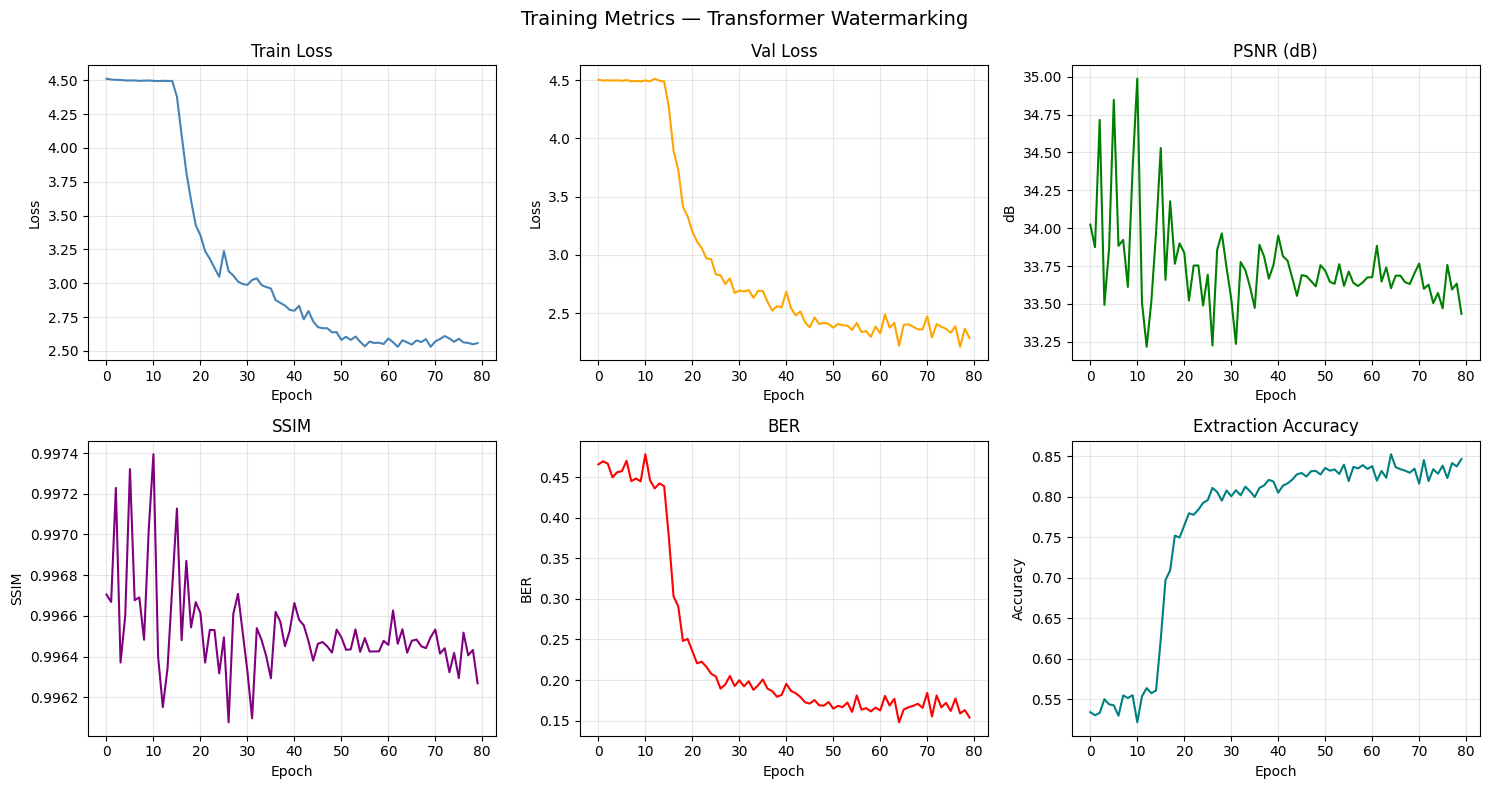

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

def plot(ax, data, title, ylabel, color='steelblue'):
    ax.plot(data, color=color)
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)

plot(axes[0,0], history['train_loss'], 'Train Loss', 'Loss')
plot(axes[0,1], history['val_loss'],   'Val Loss',   'Loss', color='orange')
plot(axes[0,2], history['psnr'],       'PSNR (dB)',  'dB',   color='green')
plot(axes[1,0], history['ssim'],       'SSIM',       'SSIM', color='purple')
plot(axes[1,1], history['ber'],        'BER',        'BER',  color='red')
plot(axes[1,2], history['acc'],        'Extraction Accuracy', 'Accuracy', color='teal')

plt.suptitle('Training Metrics — Transformer Watermarking', fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/training_curves.png', dpi=150)
plt.show()

In [18]:
# Load best checkpoint
ckpt = torch.load(f'{OUT_DIR}/best_model.pth', map_location=DEVICE)
embedder.load_state_dict(ckpt['embedder'])
extractor.load_state_dict(ckpt['extractor'])
embedder.eval(); extractor.eval()


def apply_attack(imgs, attack_name, **kw):
    """Non-differentiable attacks for eval."""
    if attack_name == 'none':
        return imgs
    elif attack_name == 'jpeg':
        # Approx JPEG: downsample + upsample
        H, W = imgs.shape[-2:]
        x = F.avg_pool2d(imgs, 4)
        return F.interpolate(x, (H, W), mode='bilinear', align_corners=False)
    elif attack_name == 'noise':
        sigma = kw.get('sigma', 0.05)
        return torch.clamp(imgs + sigma * torch.randn_like(imgs), 0, 1)
    elif attack_name == 'resize':
        H, W = imgs.shape[-2:]
        x = F.interpolate(imgs, scale_factor=0.5, mode='bilinear', align_corners=False)
        return F.interpolate(x, (H, W), mode='bilinear', align_corners=False)
    elif attack_name == 'crop':
        x = imgs.clone()
        H, W = x.shape[-2:]
        c = H // 5
        x[:, :, :c, :] = 0.5; x[:, :, -c:, :] = 0.5
        x[:, :, :, :c] = 0.5; x[:, :, :, -c:] = 0.5
        return x
    elif attack_name == 'blur':
        H, W = imgs.shape[-2:]
        x = F.avg_pool2d(imgs, 2)
        return F.interpolate(x, (H, W), mode='bilinear', align_corners=False)
    return imgs


ATTACK_NAMES = ['none', 'jpeg', 'noise', 'resize', 'crop', 'blur']
ATTACK_LABELS = ['No attack', 'JPEG compression', 'Gaussian noise',
                 'Resize', 'Crop', 'Blur']

results = {name: {'psnr': 0, 'ssim': 0, 'ber': 0, 'acc': 0}
           for name in ATTACK_NAMES}

with torch.no_grad():
    for imgs, wms in val_loader:
        imgs, wms = imgs.to(DEVICE), wms.to(DEVICE)
        watermarked = embedder(imgs, wms)

        for atk in ATTACK_NAMES:
            attacked  = apply_attack(watermarked, atk)
            wm_logits = extractor(attacked)
            results[atk]['psnr'] += psnr(imgs, watermarked)
            results[atk]['ssim'] += ssim_approx(imgs, watermarked)
            results[atk]['ber']  += ber(wms, wm_logits)
            results[atk]['acc']  += extraction_accuracy(wms, wm_logits)

n = len(val_loader)
for atk in ATTACK_NAMES:
    for k in results[atk]:
        results[atk][k] /= n

print('\nAttack Robustness Results')
print(f'{"Attack":<22} {"PSNR (dB)":>10} {"SSIM":>8} {"BER":>8} {"Acc":>8}')
print('-' * 62)
for atk, label in zip(ATTACK_NAMES, ATTACK_LABELS):
    r = results[atk]
    print(f'{label:<22} {r["psnr"]:>10.2f} {r["ssim"]:>8.4f} '
          f'{r["ber"]:>8.4f} {r["acc"]:>8.4f}')


Attack Robustness Results
Attack                  PSNR (dB)     SSIM      BER      Acc
--------------------------------------------------------------
No attack                   33.84   0.9965   0.1787   0.8213
JPEG compression            33.84   0.9965   0.4313   0.5687
Gaussian noise              33.84   0.9965   0.1847   0.8153
Resize                      33.84   0.9965   0.2519   0.7481
Crop                        33.84   0.9965   0.1950   0.8050
Blur                        33.84   0.9965   0.2519   0.7481


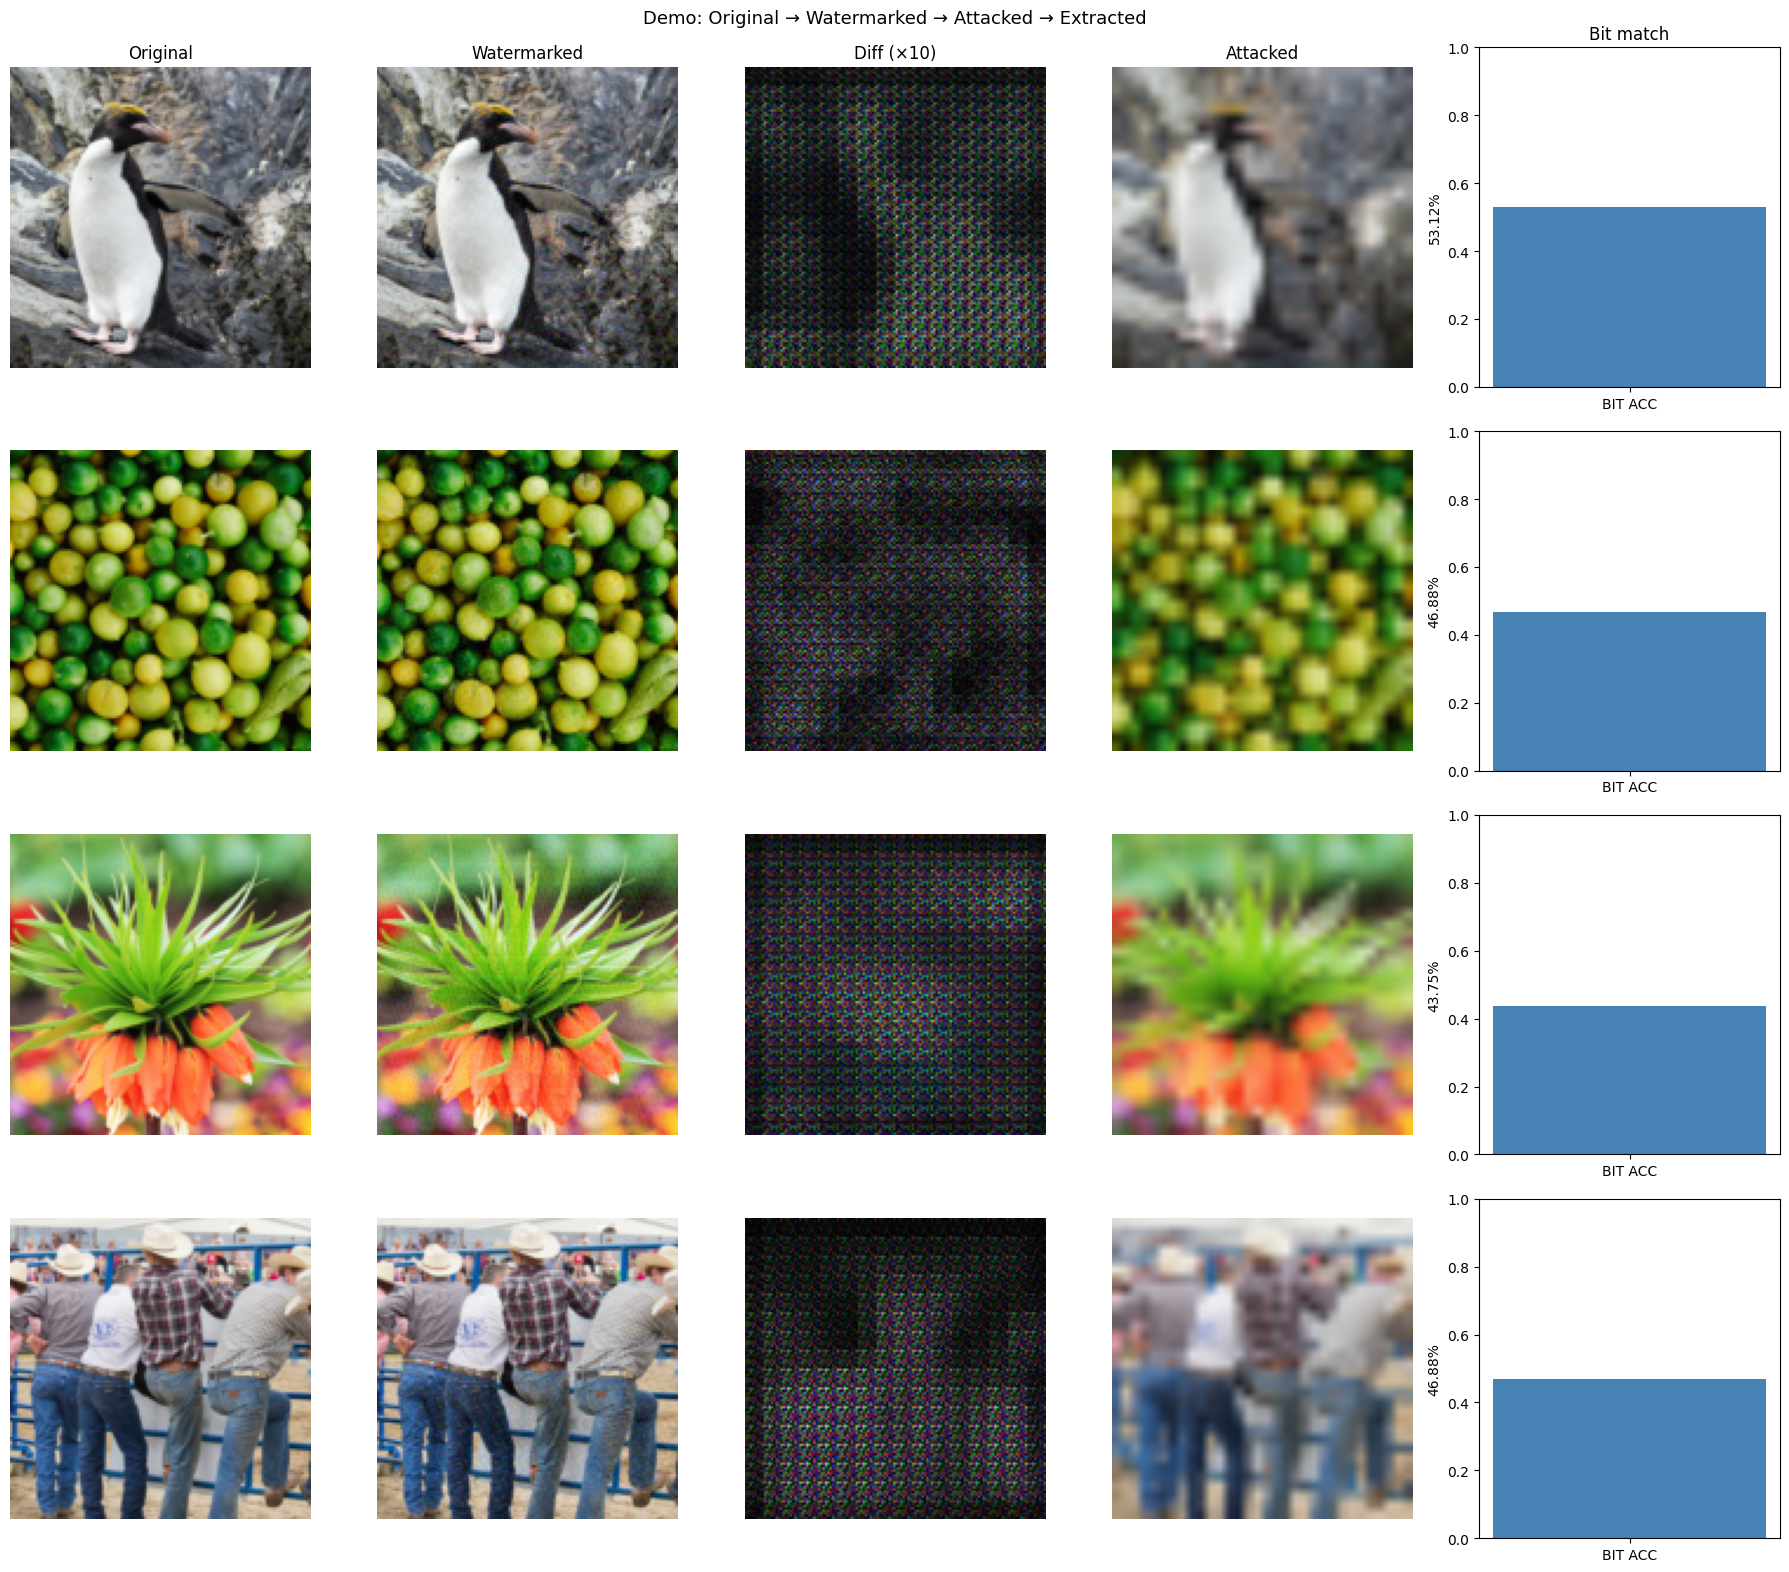

Demo saved.


In [19]:
def visualise_demo(n_samples=4):
    embedder.eval(); extractor.eval()
    imgs, wms = next(iter(val_loader))
    imgs, wms = imgs[:n_samples].to(DEVICE), wms[:n_samples].to(DEVICE)

    with torch.no_grad():
        watermarked = embedder(imgs, wms)
        diff        = (watermarked - imgs).abs() * 10   # amplified for visibility
        attacked    = apply_attack(watermarked, 'jpeg')
        logits      = extractor(attacked)
        pred_bits   = (torch.sigmoid(logits) > 0.5).float()

    def t(x): return x.cpu().permute(1, 2, 0).clamp(0, 1).numpy()

    fig, axes = plt.subplots(n_samples, 5, figsize=(18, 4 * n_samples))
    cols = ['Original', 'Watermarked', 'Diff (×10)', 'Attacked', 'Bit match']

    for i in range(n_samples):
        b_match = (pred_bits[i] == wms[i]).float().mean().item()
        for j, (img, title) in enumerate(zip(
            [imgs[i], watermarked[i], diff[i], attacked[i]], cols[:4])):
            axes[i, j].imshow(t(img))
            axes[i, j].set_title(title if i == 0 else '')
            axes[i, j].axis('off')
        # Bit accuracy panel
        axes[i, 4].bar(['BIT ACC'], [b_match], color='steelblue')
        axes[i, 4].set_ylim(0, 1)
        axes[i, 4].set_title(cols[4] if i == 0 else '')
        axes[i, 4].set_ylabel(f'{b_match:.2%}')

    plt.suptitle('Demo: Original → Watermarked → Attacked → Extracted',
                 fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/demo_visual.png', dpi=150)
    plt.show()


visualise_demo()
print('Demo saved.')

In [20]:
torch.save({'embedder':  embedder.state_dict(),
            'extractor': extractor.state_dict(),
            'history':   history,
            'config': {
                'IMG_SIZE': IMG_SIZE, 'WATERMARK_BITS': WATERMARK_BITS,
                'EMBED_DIM': EMBED_DIM, 'PATCH_SIZE': PATCH_SIZE,
                'NUM_HEADS': NUM_HEADS, 'DEPTH': DEPTH,
            }},
           f'{OUT_DIR}/final_model.pth')

print('\n=== Final model saved ===')
print(f'Outputs at : {OUT_DIR}')
print('Files      :', os.listdir(OUT_DIR))

best = min(range(EPOCHS), key=lambda i: history['val_loss'][i])
print(f'\nBest epoch : {best + 1}')
print(f'  PSNR     : {history["psnr"][best]:.2f} dB  (target > 30 dB)')
print(f'  SSIM     : {history["ssim"][best]:.4f}     (target > 0.90)')
print(f'  BER      : {history["ber"][best]:.4f}      (target < 0.10)')
print(f'  Acc      : {history["acc"][best]:.4f}      (target > 0.90)')


=== Final model saved ===
Outputs at : /kaggle/working/outputs
Files      : ['training_curves.png', 'best_model_ft2.pth', 'best_model_ber.pth', 'best_model.pth', 'final_model.pth', 'best_model_ft.pth', 'demo_visual.png']

Best epoch : 78
  PSNR     : 33.59 dB  (target > 30 dB)
  SSIM     : 0.9964     (target > 0.90)
  BER      : 0.1588      (target < 0.10)
  Acc      : 0.8413      (target > 0.90)
